In [88]:
import numpy as np  
import matplotlib.pyplot as plt

(35.0, 50.0)

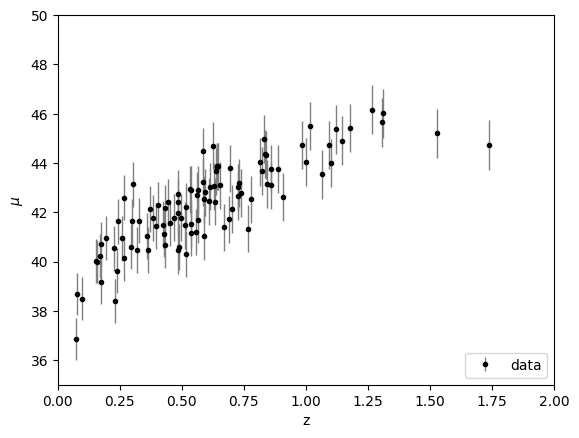

In [89]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


### Let's perform a GPR 

In [90]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, DotProduct 


# Radial basis function kernel RBF 
kernel1 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) #one possible kernel choice

z = np.linspace(0.01, 2, 1000)

gp = GaussianProcessRegressor(kernel=kernel1, alpha=dmu ** 2)

gp.fit(z_sample[:, None], mu_sample)            #fit the data 
mu_fit, sigma = gp.predict(z[:, None], return_std=True)             #return the main, Standard deviation of predictive distribution


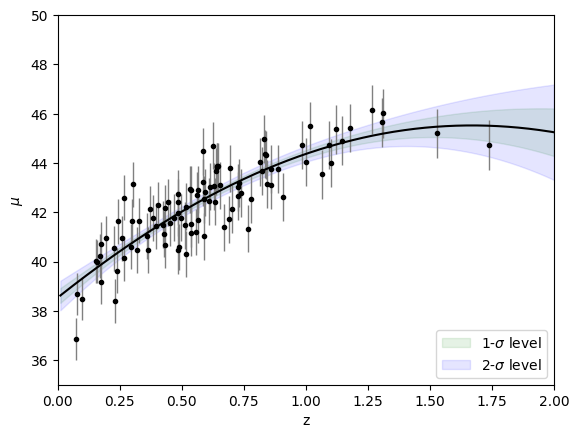

In [91]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

plt.plot(z, mu_fit, '-k')

plt.fill_between(z, mu_fit - sigma, mu_fit + sigma, alpha=0.1, color='g', label='1-$\sigma$ level')

plt.fill_between(z, mu_fit - 2* sigma, mu_fit + 2* sigma, alpha=0.1, color='b', label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

### Cross validation to chose the Kernel Hyperparameter

There is already an optimization of the kernel Hyperparameter (indeed with we give a initial guess and an interval) so I cross validate using different Kernel

In [92]:
from sklearn.model_selection import GridSearchCV, KFold

kernels= [ConstantKernel(1.0, (1e-3, 1e4)) * RBF(10, (1e-2, 1e3)),
          ConstantKernel(1.0, (1e-3, 1e4)),
          RBF(10, (1e-2, 1e3)), 
          Matern(1.0, (1e-3, 1e3))]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "kernel": kernels
}

gpr = GaussianProcessRegressor(kernel=kernels,alpha=0.9) 
search = GridSearchCV(
    estimator=gpr,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_squared_error",  # puoi anche usare R^2 o MAE
    n_jobs=-1,
    verbose=1
)

search.fit(z_sample[:, None], mu_sample)


Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GaussianProcessRegressor(alpha=0.9,
                                                kernel=[1**2 * RBF(length_scale=10),
                                                        1**2,
                                                        RBF(length_scale=10),
                                                        Matern(length_scale=1, nu=1.5)]),
             n_jobs=-1,
             param_grid={'kernel': [1**2 * RBF(length_scale=10), 1**2,
                                    RBF(length_scale=10),
                                    Matern(length_scale=1, nu=1.5)]},
             scoring='neg_mean_squared_error', verbose=1)

Best kernel: 30.6**2 * RBF(length_scale=3.93)


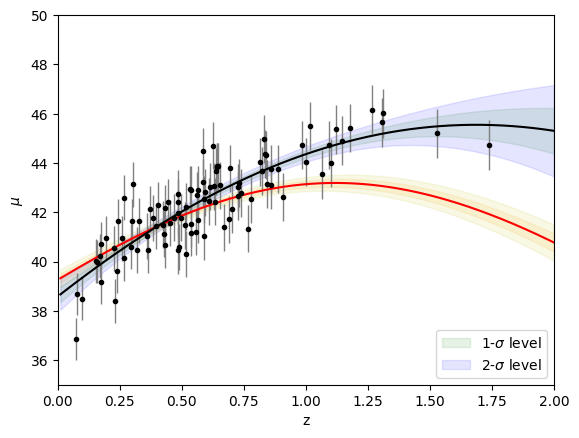

In [93]:
gp_best = search.best_estimator_
print("Best kernel:", gp_best.kernel_)

mu_fit2, sigma2 = gp_best.predict(z[:, None], return_std=True)

kernel2=Matern(1.0, (1e-3, 1e3))
gp3 = GaussianProcessRegressor(kernel=kernel2, alpha=dmu ** 2)

gp3.fit(z_sample[:, None], mu_sample)            #fit the data 
mu_fit3, sigma3 = gp3.predict(z[:, None], return_std=True)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

plt.plot(z, mu_fit3, '-r')

plt.fill_between(z, mu_fit3 - sigma3, mu_fit3 + sigma3, alpha=0.1, color='orange')

plt.fill_between(z, mu_fit3 - 2* sigma3, mu_fit3 + 2* sigma3, alpha=0.1, color='y')

plt.plot(z, mu_fit2, '-k')

plt.fill_between(z, mu_fit2 - sigma2, mu_fit2 + sigma2, alpha=0.1, color='g', label='1-$\sigma$ level')

plt.fill_between(z, mu_fit2 - 2* sigma2, mu_fit2 + 2* sigma2, alpha=0.1, color='b', label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


### Cloning data

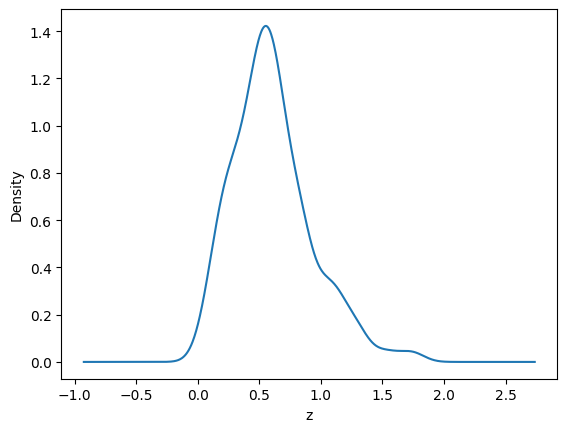

In [94]:
#VISUALIZE THE DISTRIBUTION OF DATA in z

from sklearn.neighbors import KernelDensity

z_vals = np.array(z_sample).reshape(-1, 1) 

kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('Density')
plt.show()

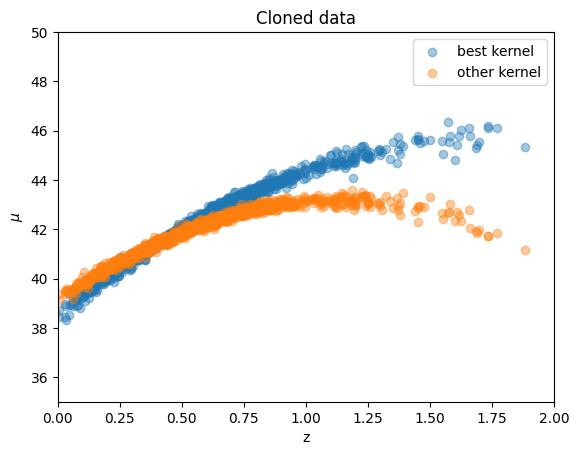

In [95]:
N = 1000
new_z_samples = kde.sample(N)               #N values that follow the pdf of z estimated by KDE

#now given the z (distributed as our sample)
mu_gpr=[]
mu_gprm=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp_best.predict([[z]], return_std=True)
    mu_fitm, sigmam = gp3.predict([[z]], return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))     #each data has also errors, which are randomly distributed with sigma
    mu_gprm.append(np.random.normal(loc=mu_fitm,scale=sigmam)) 
    
plt.scatter(new_z_samples,mu_gpr,alpha=0.4, label='best kernel')
plt.scatter(new_z_samples,mu_gprm,alpha=0.4, label='other kernel')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.legend()
plt.title("Cloned data");

### Part 3 : non linear fitting  following $\Lambda CDM$

In [96]:
import emcee
import scipy.stats as scistats
import corner
import dynesty
from astropy.cosmology import LambdaCDM

In [101]:
def generativemodel(z, H0, Om=1):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om) #assuming a flat universe 
    return cosmo_tmp.distmod(z).value 

generativemodel(np.random.uniform(0,2,10), 50, 0.1)

array([39.24971688, 45.72946886, 44.53212897, 42.05078819, 43.36298772,
       39.52739913, 47.107053  , 47.10796109, 40.27750989, 44.39950763])